In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

from category_encoders import TargetEncoder

In [2]:
df = pd.read_excel("../data/cleaned/df_cleaned.xlsx")

In [3]:
df.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL
0,1.6,4,A4,X,10.5,216,ACURA,1.6EL
1,1.6,4,M5,X,9.8,205,ACURA,1.6EL
2,3.2,6,AS5,Z,13.7,265,ACURA,3.2TL
3,3.5,6,A4,Z,15.0,301,ACURA,3.5RL
4,1.8,4,A4,X,11.4,230,ACURA,INTEGRA


In [4]:
X = df.drop(labels='COEMISSIONS', axis=1)
y = df["COEMISSIONS"]

In [5]:
X.dtypes

ENGINE SIZE         float64
CYLINDERS             int64
TRANSMISSION         object
FUEL                 object
FUEL CONSUMPTION    float64
MAKE                 object
MODEL                object
dtype: object

In [6]:
categorical_cols = ['TRANSMISSION', 'FUEL', 'MAKE', 'MODEL']
numeric_cols = ['ENGINE SIZE', 'CYLINDERS', 'FUEL CONSUMPTION']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [8]:
# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("target_enc", TargetEncoder(smoothing=10), categorical_cols),
        ("num", RobustScaler(), numeric_cols)
    ]
)

# Full pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", ElasticNet(max_iter=10000))
])

# Hyperparameter grid
param_grid = {
    "model__alpha": np.logspace(-4, 1, 20),
    "model__l1_ratio": np.linspace(0.1, 0.9, 9)
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...00000000e+01]), 'model__l1_ratio': array([0.1, 0....7, 0.8, 0.9])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [9]:
print("Best parameters:", grid.best_params_)

Best parameters: {'model__alpha': np.float64(0.0001), 'model__l1_ratio': np.float64(0.9)}


In [10]:
y_pred = grid.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

performance_matrix = pd.DataFrame({"Values":[mse,rmse,mae,r2]}, index=["MSE","RMSE","MAE","R2 Score"])
performance_matrix

,Values
MSE,332.778127
RMSE,18.242207
MAE,12.104134
R2 Score,0.929100


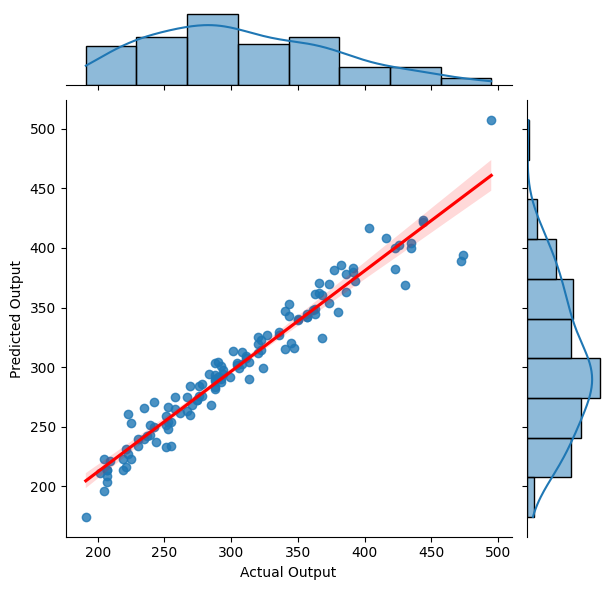

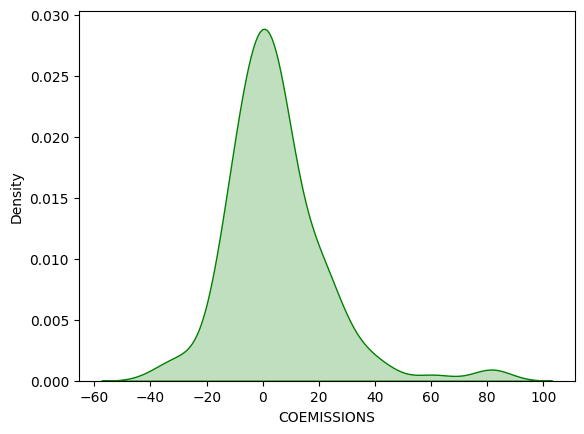

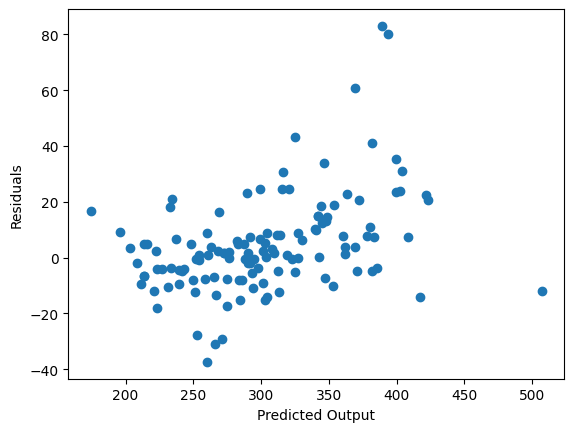

In [12]:
sns.jointplot(x=y_test, y=y_pred, kind='reg', line_kws={"color": "red"})
plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.savefig("reports/actual_vs_predicted_output.png", dpi=300, bbox_inches="tight")
plt.show()

residuals = y_test - y_pred
# densityplot this residuals
sns.kdeplot(data=residuals,fill=True, color='g')
plt.savefig("reports/residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# scatter plot with respect to prediction and residuals
plt.scatter(x=y_pred, y=residuals)
plt.xlabel("Predicted Output")
plt.ylabel("Residuals")
plt.savefig("reports/predicted_vs_residual.png", dpi=300, bbox_inches="tight")
plt.show()